In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# --- 1. Neural Network Definition (IMPROVED) ---
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        # --- IMPROVEMENT: SiLU is often better for PINNs than Tanh ---
        self.activation = nn.SiLU()
        self.layers = nn.ModuleList()
        
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

        # --- IMPROVEMENT: Add Glorot (Xavier) Initialization ---
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                # Apply Glorot (Xavier) uniform initialization
                nn.init.xavier_uniform_(layer.weight)
                # Initialize biases to zero
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        # No activation on the final layer
        x = self.layers[-1](x)
        return x

In [3]:
# --- 2. The Main Physics-Informed Class (IMPROVED) ---
class BoussinesqPINN:
    # Add 'total_epochs' to the __init__ signature
    def __init__(self, network, nu, p_val, a_val, domain_r, domain_z, total_epochs):
        self.network = network.to(device)
        self.nu = nu
        self.p_val = p_val # p from your formula (e.g., 1000)
        self.a_val = a_val # a from your formula (e.g., 0.1)
        
        # --- NEW: Store domain for resampling ---
        self.R_DOMAIN = domain_r
        self.Z_DOMAIN = domain_z

        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=1e-3, amsgrad=True)
        
        # --- FIX: Replaced ReduceLROnPlateau with CosineAnnealingLR ---
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=total_epochs, eta_min=1e-7
        )

        # --- IMPROVEMENT: Re-balanced Loss weights ---
        # The PDE loss was being ignored. We MUST force the network
        # to respect the physics.
        self.w_pde = 100.0 # Was 10.0
        self.w_bc  = 1.0 # Was 100.0

        self.Total_loss, self.Loss_pde, self.Loss_bc, self.Loss_surface = [], [], [], []
    
    # --- NEW: Point Sampling Method ---
    def sample_points(self, n_pde, n_bc):
        """
        Resample all collocation points for each training step.
        """
        # 1. PDE Points (with bias near load)
        N_REGULAR = int(n_pde * 0.6)
        r_pde_reg = torch.sqrt(torch.rand(N_REGULAR, 1)) * self.R_DOMAIN
        z_pde_reg = torch.rand(N_REGULAR, 1) * self.Z_DOMAIN

        N_SINGULARITY = int(n_pde * 0.25)
        r_pde_sing = torch.sqrt(torch.rand(N_SINGULARITY, 1)) * (self.a_val * 1.5) 
        z_pde_sing = torch.rand(N_SINGULARITY, 1) * (self.Z_DOMAIN * 0.05)

        N_SURFACE_BIAS = int(n_pde * 0.15)
        r_pde_surf = torch.sqrt(torch.rand(N_SURFACE_BIAS, 1)) * self.R_DOMAIN
        z_pde_surf = torch.rand(N_SURFACE_BIAS, 1) * (self.Z_DOMAIN * 0.1)

        r_pde = torch.cat([r_pde_reg, r_pde_sing, r_pde_surf], dim=0)
        z_pde = torch.cat([z_pde_reg, z_pde_sing, z_pde_surf], dim=0)
        pde_pts = torch.cat([r_pde, z_pde], dim=1).to(device)
        
        # 2. BC Points
        # Surface
        r_surface = torch.rand(n_bc, 1) * self.R_DOMAIN
        r_surface[r_surface == 0] = 1e-8
        surface_pts = torch.cat([r_surface, torch.zeros_like(r_surface)], dim=1).to(device)

        # Far-field
        r_far_vert = self.R_DOMAIN * torch.ones(n_bc // 2, 1)
        z_far_vert = self.Z_DOMAIN * torch.rand(n_bc // 2, 1)
        r_far_horiz = self.R_DOMAIN * torch.rand(n_bc // 2, 1)
        z_far_horiz = self.Z_DOMAIN * torch.ones(n_bc // 2, 1)
        far_field_pts = torch.cat([
            torch.cat([r_far_vert, z_far_vert], dim=1),
            torch.cat([r_far_horiz, z_far_horiz], dim=1)
        ], dim=0).to(device)

        # Axis
        r_axis = torch.full((n_bc, 1), 1e-8)
        z_axis = torch.rand(n_bc, 1) * self.Z_DOMAIN
        axis_pts = torch.cat([r_axis, z_axis], dim=1).to(device)
        
        return pde_pts, surface_pts, far_field_pts, axis_pts

    # --- (PDE, Stress, and helper functions are unchanged) ---
    def _get_pde_residuals(self, r, z):
        r.requires_grad_(True)
        z.requires_grad_(True)
        net_out = self.network(torch.cat([r, z], dim=1))
        phi, psi = net_out[:, 0:1], net_out[:, 1:2]
        phi_r = torch.autograd.grad(phi, r, torch.ones_like(phi), create_graph=True)[0]
        phi_rr = torch.autograd.grad(phi_r, r, torch.ones_like(phi_r), create_graph=True)[0]
        phi_z = torch.autograd.grad(phi, z, torch.ones_like(phi), create_graph=True)[0]
        phi_zz = torch.autograd.grad(phi_z, z, torch.ones_like(phi_z), create_graph=True)[0]
        r_safe = torch.clamp(r, min=1e-6)
        laplacian_phi = phi_rr + (1 / r_safe) * phi_r + phi_zz
        psi_r = torch.autograd.grad(psi, r, torch.ones_like(psi), create_graph=True)[0]
        psi_rr = torch.autograd.grad(psi_r, r, torch.ones_like(psi_r), create_graph=True)[0]
        psi_z = torch.autograd.grad(psi, z, torch.ones_like(psi), create_graph=True)[0]
        psi_zz = torch.autograd.grad(psi_z, z, torch.ones_like(psi_z), create_graph=True)[0]
        laplacian_psi = psi_rr + (1 / r_safe) * psi_r + psi_zz
        pde_residual_1 = laplacian_phi - psi
        pde_residual_2 = laplacian_psi
        return pde_residual_1, pde_residual_2

    def compute_stresses(self, r, z):
        r.requires_grad_(True)
        z.requires_grad_(True)
        net_out = self.network(torch.cat([r, z], dim=1))
        phi, psi = net_out[:, 0:1], net_out[:, 1:2]
        phi_z = torch.autograd.grad(phi, z, torch.ones_like(phi), create_graph=True)[0]
        phi_zz = torch.autograd.grad(phi_z, z, torch.ones_like(phi_z), create_graph=True)[0]
        sigma_zz_term = (2 - self.nu) * psi - phi_zz
        sigma_zz = torch.autograd.grad(sigma_zz_term, z, torch.ones_like(sigma_zz_term), create_graph=True)[0]
        tau_rz_term = (1 - self.nu) * psi - phi_zz
        tau_rz = torch.autograd.grad(tau_rz_term, r, torch.ones_like(tau_rz_term), create_graph=True)[0]
        return sigma_zz, tau_rz

    def _get_phi_r(self, r, z):
        r.requires_grad_(True)
        z.requires_grad_(True)
        net_out = self.network(torch.cat([r, z], dim=1))
        phi = net_out[:, 0:1]
        phi_r = torch.autograd.grad(phi, r, torch.ones_like(phi), create_graph=True)[0]
        return phi_r
    
    def _get_polynomial_load(self, r):
        p = self.p_val
        a = self.a_val
        term1 = p / (a**7)
        term2 = (6 * r + a)
        term3 = (r - a)**6
        f_r = term1 * term2 * term3
        mask = (r <= a).float()
        return f_r * mask

    # --- (Loss function is unchanged, but will use new weights) ---
    def loss_function(self, pde_pts, surface_pts, far_field_pts, axis_pts):
        r_pde, z_pde = pde_pts[:, 0:1], pde_pts[:, 1:2]
        pde_res_1, pde_res_2 = self._get_pde_residuals(r_pde, z_pde)
        loss_pde = torch.mean(r_pde * (pde_res_1**2)) + torch.mean(r_pde * (pde_res_2**2))

        r_surf, z_surf = surface_pts[:, 0:1], surface_pts[:, 1:2]
        sigma_zz_surf, tau_rz_surf = self.compute_stresses(r_surf, z_surf)
        target_f_r = self._get_polynomial_load(r_surf)
        target_sigma_zz = -target_f_r
        loss_bc_sigma_zz = torch.mean((sigma_zz_surf - target_sigma_zz)**2)
        loss_bc_tau_rz = torch.mean(tau_rz_surf**2)
        loss_bc_surface = loss_bc_sigma_zz + loss_bc_tau_rz
        
        r_far, z_far = far_field_pts[:, 0:1], far_field_pts[:, 1:2]
        sigma_zz_far, tau_rz_far = self.compute_stresses(r_far, z_far)
        loss_bc_far_field = torch.mean(sigma_zz_far**2) + torch.mean(tau_rz_far**2)

        r_axis, z_axis = axis_pts[:, 0:1], axis_pts[:, 1:2]
        phi_r_axis = self._get_phi_r(r_axis, z_axis)
        loss_bc_axis = torch.mean(phi_r_axis**2)

        loss_bc = loss_bc_surface + loss_bc_far_field + loss_bc_axis
        
        total_loss = (self.w_pde * loss_pde + 
                      self.w_bc * loss_bc)
        
        return total_loss, loss_pde, loss_bc, loss_bc_surface

    # --- IMPROVEMENT: TRAIN METHOD (with resampling) ---
    def train(self, epochs, n_pde, n_bc):
        
        print("--- Starting Training (Distributed Load, Resampling) ---")

        for epoch in range(epochs):
            
            self.network.train()
            self.optimizer.zero_grad()
            
            # --- RESAMPLING: Get new points every epoch ---
            pde_pts, surface_pts, far_field_pts, axis_pts = self.sample_points(n_pde, n_bc)
            
            loss, loss_pde, loss_bc, loss_surf = self.loss_function(
                pde_pts, surface_pts, far_field_pts, axis_pts
            )
            
            loss.backward()
            self.optimizer.step()
            self.scheduler.step()

            self.Total_loss.append(loss.item())
            self.Loss_pde.append(loss_pde.item())
            self.Loss_bc.append(loss_bc.item())
            self.Loss_surface.append(loss_surf.item())
            
            if epoch % 1000 == 0 or epoch == epochs - 1: 
                print(f"Epoch {epoch+1}/{epochs} -> Total Loss: {loss.item():.4e}, "
                      f"PDE: {loss_pde.item():.4e}, BC: {loss_bc.item():.4e}, Surf_BC: {loss_surf.item():.4e}, "
                      f"LR: {self.optimizer.param_groups[0]['lr']:.2e}")

In [4]:
# --- 3. Main Execution Block (IMPROVED) ---

# Problem Parameters
NU = 0.3 
R_DOMAIN = 10.0 
Z_DOMAIN = 10.0 

# Polynomial Load Parameters
P_VAL = 1000.0
A_VAL = 0.1

# --- IMPROVEMENT: More points for better accuracy ---
N_PDE = 10000  # Was 8000
N_BC = 2500   # Was 1500

# --- Point sampling logic is now in the BoussinesqPINN class ---
print(f"Training with N_PDE={N_PDE}, N_BC={N_BC} (resampled each epoch)\n")

# --- IMPROVEMENT: Larger network for more capacity ---
layers = [2, 120, 120, 120, 120, 2] # Was [2, 50, 50, 50, 50, 50, 2]
pinn_net = PINN(layers).to(device)

# --- IMPROVEMENT: Longer training run ---
TOTAL_EPOCHS = 20000 # Was 10000

# --- MODIFIED: Initialize the new solver with domain info ---
boussinesq_solver = BoussinesqPINN(
    pinn_net, 
    nu=NU, 
    p_val=P_VAL, 
    a_val=A_VAL,
    domain_r=R_DOMAIN,
    domain_z=Z_DOMAIN,
    total_epochs=TOTAL_EPOCHS  # <-- Pass the total epochs here
)

# --- MODIFIED: Simplified training call ---
boussinesq_solver.train(
    TOTAL_EPOCHS, 
    N_PDE, 
    N_BC
)
print("\n--- Training Complete ---")

torch.save(boussinesq_solver.network.state_dict(), 'boussinesq_model_distributed_load_v2.pth')
print("Model saved to boussinesq_model_distributed_load_v2.pth")

Training with N_PDE=10000, N_BC=2500 (resampled each epoch)

--- Starting Training (Distributed Load, Resampling) ---
Epoch 1/20000 -> Total Loss: 1.2218e+03, PDE: 2.7666e-01, BC: 1.1942e+03, Surf_BC: 1.1942e+03, LR: 1.00e-03
Epoch 1001/20000 -> Total Loss: 7.9331e+01, PDE: 3.4160e-02, BC: 7.5915e+01, Surf_BC: 7.5889e+01, LR: 9.94e-04
Epoch 2001/20000 -> Total Loss: 5.6503e+01, PDE: 4.2046e-02, BC: 5.2299e+01, Surf_BC: 5.2288e+01, LR: 9.76e-04
Epoch 3001/20000 -> Total Loss: 2.0964e+01, PDE: 2.0665e-02, BC: 1.8898e+01, Surf_BC: 1.8892e+01, LR: 9.45e-04
Epoch 4001/20000 -> Total Loss: 8.5467e+00, PDE: 1.7338e-02, BC: 6.8130e+00, Surf_BC: 6.8117e+00, LR: 9.04e-04
Epoch 5001/20000 -> Total Loss: 6.3511e+00, PDE: 5.4936e-03, BC: 5.8017e+00, Surf_BC: 5.8002e+00, LR: 8.54e-04
Epoch 6001/20000 -> Total Loss: 3.4494e+00, PDE: 6.8939e-03, BC: 2.7600e+00, Surf_BC: 2.7572e+00, LR: 7.94e-04
Epoch 7001/20000 -> Total Loss: 1.0500e+00, PDE: 3.8150e-03, BC: 6.6847e-01, Surf_BC: 6.6587e-01, LR: 7.27e-


--- Plotting Learning Curve ---


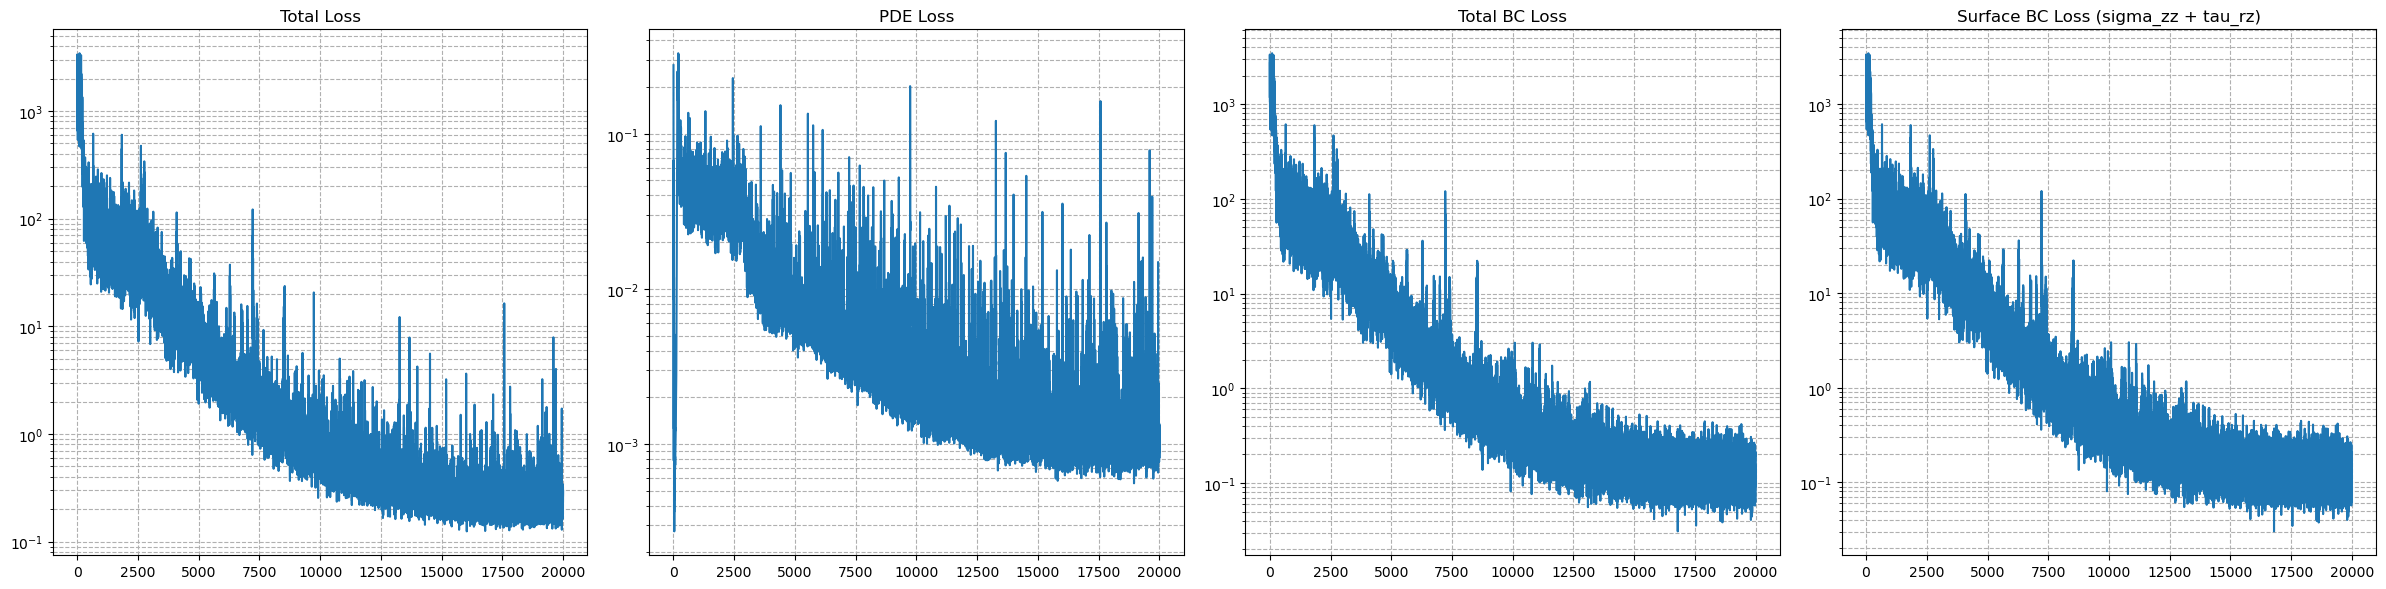

In [6]:
# --- 4. Plotting (Modified for new loss names) ---

print("\n--- Plotting Learning Curve ---")

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Total Loss
axes[0].plot(boussinesq_solver.Total_loss)
axes[0].set_title('Total Loss')
axes[0].set_yscale('log')
axes[0].grid(True, which="both", ls="--")

# PDE Loss
axes[1].plot(boussinesq_solver.Loss_pde)
axes[1].set_title('PDE Loss')
axes[1].set_yscale('log')
axes[1].grid(True, which="both", ls="--")

# BC Loss (All)
axes[2].plot(boussinesq_solver.Loss_bc)
axes[2].set_title('Total BC Loss')
axes[2].set_yscale('log')
axes[2].grid(True, which="both", ls="--")

# --- MODIFIED: Surface BC Loss ---
axes[3].plot(boussinesq_solver.Loss_surface)
axes[3].set_title('Surface BC Loss (sigma_zz + tau_rz)')
axes[3].set_yscale('log')
axes[3].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()


--- Verifying Results ---


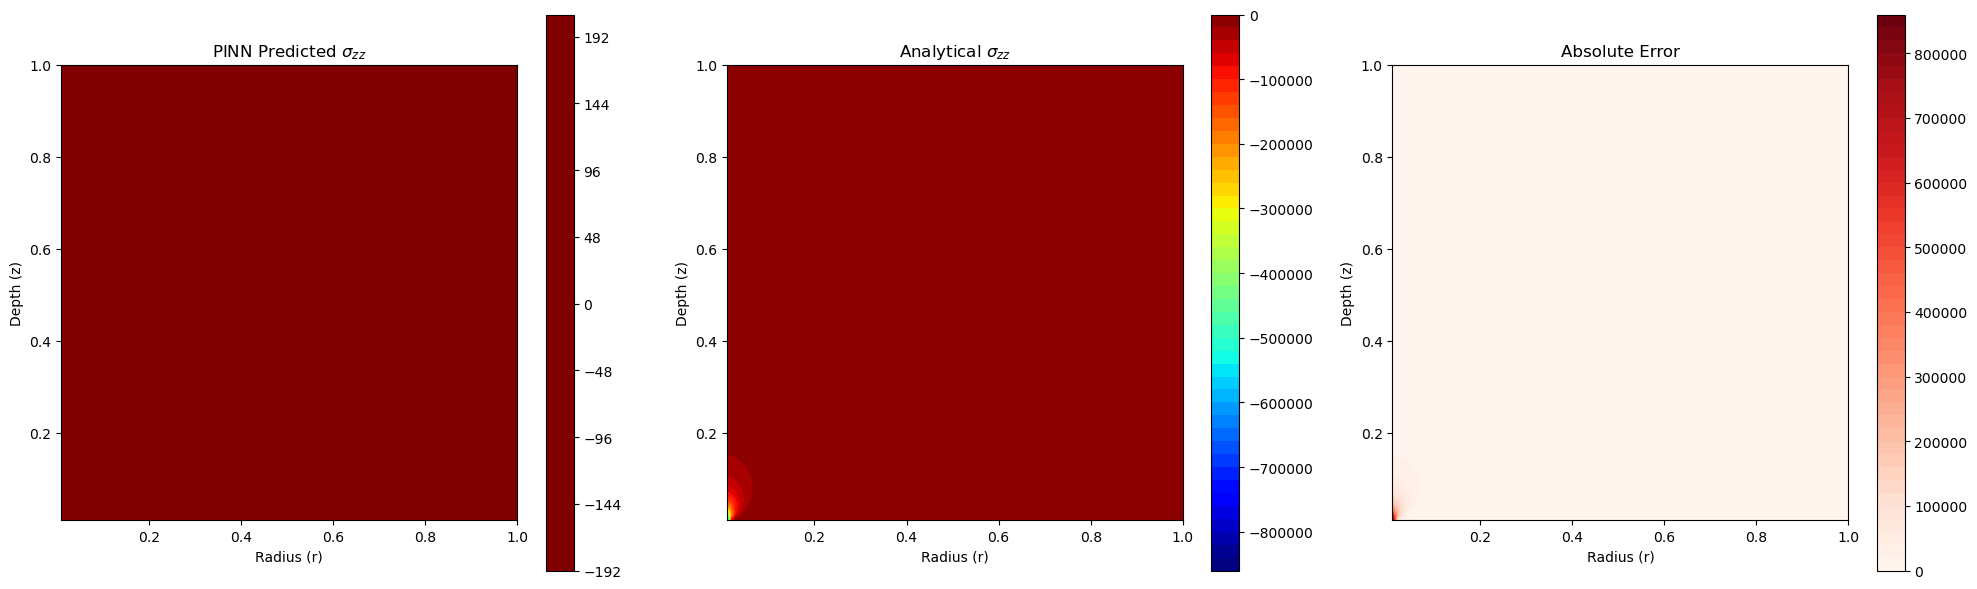

In [7]:
print("\n--- Verifying Results ---")

P = 1_000  # Total load magnitude

grid_res = 100
r_plot = np.linspace(0.01, 1, grid_res)
z_plot = np.linspace(0.01, 1, grid_res)
R_grid, Z_grid = np.meshgrid(r_plot, z_plot)

r_tensor = torch.tensor(R_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)
z_tensor = torch.tensor(Z_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)

pinn_net.eval()
r_tensor.requires_grad_(True)
z_tensor.requires_grad_(True)
sigma_zz_pred, _ = boussinesq_solver.compute_stresses(r_tensor, z_tensor)
sigma_zz_pinn = sigma_zz_pred.cpu().detach().numpy().reshape(R_grid.shape)

def analytical_sigma_zz(r, z, P):
    return (-3 * P / (2 * np.pi)) * (z**3) / ((r**2 + z**2)**(5/2))

sigma_zz_analytical = analytical_sigma_zz(R_grid, Z_grid, P)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

vmin = sigma_zz_analytical.min()
vmax = 0 

c1 = axes[0].contourf(R_grid, Z_grid, sigma_zz_pinn, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axes[0].set_title("PINN Predicted $\\sigma_{zz}$")
axes[0].set_xlabel("Radius (r)")
axes[0].set_ylabel("Depth (z)")
fig.colorbar(c1, ax=axes[0])
axes[0].set_aspect('equal')

c2 = axes[1].contourf(R_grid, Z_grid, sigma_zz_analytical, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axes[1].set_title("Analytical $\\sigma_{zz}$")
axes[1].set_xlabel("Radius (r)")
axes[1].set_ylabel("Depth (z)")
fig.colorbar(c2, ax=axes[1])
axes[1].set_aspect('equal')

error = np.abs(sigma_zz_pinn - sigma_zz_analytical)
c3 = axes[2].contourf(R_grid, Z_grid, error, levels=50, cmap='Reds')
axes[2].set_title("Absolute Error")
axes[2].set_xlabel("Radius (r)")
axes[2].set_ylabel("Depth (z)")
fig.colorbar(c3, ax=axes[2])
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()